# Exploratory Data Analysis - Eksoplanet

## Tentang data

Data hasil scraping dua halaman Wikipedia (eksoplanet yang ditemukan tahun 2014 dan 2016), disimpan di `eksoplanet.csv`.

- satu baris = satu planet;
- 11 kolom: `nama`, 8 kolom numerik (planet dan bintang induk), `metode_deteksi`, `tahun_penemuan`.

Notebook ini **hanya EDA**: masalah pada data diidentifikasi dan dicatat, penanganannya dilakukan pada tahap preprocessing.

### Penjelasan fitur

**Eksoplanet** adalah planet yang mengorbit bintang selain Matahari. Setiap baris berisi sifat planet, sifat orbitnya, sifat bintang induknya, dan cara planet itu ditemukan.

#### Identitas

| Kolom | Tipe | Satuan | Penjelasan |
|---|---|---|---|
| `nama` | teks | - | Nama resmi planet. Umumnya **nama bintang induk + huruf kecil** (b, c, d, ...) sesuai urutan penemuan. Awalan nama menunjukkan katalog atau survei asal, misalnya `Kepler-` (teleskop Kepler), `K2-` (misi lanjutan Kepler), `WASP-`, `HAT-P-` (survei darat), `HD`/`HIP` (katalog bintang), `OGLE-` (survei microlensing). |

#### Sifat planet

| Kolom | Tipe | Satuan | Penjelasan |
|---|---|---|---|
| `massa_mj` | numerik | massa Jupiter (MJ) | Massa planet dibandingkan massa Jupiter. 1 MJ ≈ 318 massa Bumi, sehingga Bumi ≈ 0,003 MJ dan Neptunus ≈ 0,054 MJ. Objek > 13 MJ umumnya tergolong **katai coklat**, bukan planet. Untuk metode radial velocity, nilai ini biasanya **massa minimum**. |
| `radius_rj` | numerik | radius Jupiter (RJ) | Jari-jari planet dibandingkan jari-jari Jupiter. 1 RJ ≈ 11,2 radius Bumi (≈ 71.500 km), sehingga Bumi ≈ 0,09 RJ. Nilai ≈ 1 RJ berarti planet raksasa gas; 0,09-0,36 RJ berarti planet seukuran super-Bumi hingga sub-Neptunus. |
| `suhu_planet_k` | numerik | Kelvin (K) | **Suhu kesetimbangan** planet: perkiraan suhu dari panas yang diterima dari bintangnya (bukan hasil pengukuran langsung permukaan). 0 °C = 273 K; Bumi ≈ 255 K. Planet yang sangat dekat bintang bisa > 1.000 K. |

#### Sifat orbit

| Kolom | Tipe | Satuan | Penjelasan |
|---|---|---|---|
| `periode_hari` | numerik | hari | **Periode orbit**: waktu yang dibutuhkan planet untuk satu kali mengelilingi bintangnya (satu "tahun" planet). Bumi = 365,25 hari. |
| `sumbu_semimayor_au` | numerik | satuan astronomi (AU) | **Sumbu semimayor**: setengah sumbu terpanjang orbit elips, secara sederhana **jarak rata-rata planet ke bintangnya**. 1 AU = jarak Bumi-Matahari ≈ 150 juta km; Merkurius ≈ 0,39 AU. Berhubungan erat dengan `periode_hari` melalui hukum Kepler III (a³ ∝ P² × M bintang). |

#### Sifat bintang induk dan posisi

| Kolom | Tipe | Satuan | Penjelasan |
|---|---|---|---|
| `jarak_tahun_cahaya` | numerik | tahun cahaya | Jarak sistem planet dari **Bumi** (bukan dari bintangnya). 1 tahun cahaya ≈ 9,46 triliun km. Bintang terdekat selain Matahari ≈ 4,2 tahun cahaya; pusat galaksi ≈ 26.000 tahun cahaya. |
| `massa_bintang_msun` | numerik | massa Matahari (Msun) | Massa bintang yang diorbit planet. 1 Msun ≈ 1.048 MJ. Nilai < 0,5 umumnya **katai merah**; nilai ≈ 1 berarti bintang mirip Matahari. |
| `suhu_bintang_k` | numerik | Kelvin (K) | Suhu permukaan (efektif) bintang induk. Matahari ≈ 5.772 K. Bintang < 4.000 K berwarna kemerahan (tipe M/K), 5.000-6.000 K mirip Matahari (tipe G), > 7.000 K bintang panas kebiruan (tipe A/F). |

#### Penemuan

| Kolom | Tipe | Satuan | Penjelasan |
|---|---|---|---|
| `metode_deteksi` | kategorik | - | Teknik yang dipakai untuk menemukan planet (5 kategori, dijelaskan di bawah). Metode menentukan **besaran apa yang bisa diukur**, sehingga sangat memengaruhi kolom mana yang terisi. |
| `tahun_penemuan` | kategorik (disimpan sebagai angka) | tahun | Tahun planet diumumkan: **2014** atau **2016**, sesuai halaman Wikipedia sumbernya. |

Kategori `metode_deteksi`:

1. **transit**: cahaya bintang meredup sedikit secara berkala saat planet melintas di depannya. Menghasilkan **radius** dan **periode**, tetapi tidak massa. Paling mudah menemukan planet dengan periode pendek.
2. **radial vel.** (*radial velocity*, kecepatan radial): bintang "bergoyang" karena tarikan gravitasi planet, terlihat dari pergeseran Doppler pada spektrum cahayanya. Menghasilkan **massa** dan **periode**, tetapi tidak radius.
3. **microlensing**: gravitasi bintang (dan planetnya) membelokkan dan memperkuat cahaya bintang lain di belakangnya. Hanya terjadi sekali, sehingga tidak menghasilkan periode; cocok untuk sistem yang sangat jauh.
4. **timing**: planet dideteksi dari perubahan waktu sinyal yang seharusnya teratur, misalnya denyut pulsar, gerhana bintang ganda, atau pergeseran waktu transit planet lain.
5. **imaging**: planet dipotret langsung dengan menutupi cahaya bintangnya. Hanya bisa untuk planet besar, muda (masih panas), dan jauh dari bintangnya; periodenya terlalu panjang untuk diamati.

## 1. Import library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns                       # visualisasi
import matplotlib.pyplot as plt             # visualisasi
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
%matplotlib inline

# Palet grafik
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BIRU, ORANYE, AQUA, ABU = "#2a78d6", "#eb6834", "#1baf7a", "#f0efec"
WARNA_METODE = {"transit": BIRU, "radial vel.": ORANYE, "lainnya": AQUA}
CMAP_DIVERGING = LinearSegmentedColormap.from_list("biru_merah", ["#184f95", "#6da7ec", ABU, "#ec8a89", "#b3302f"])
CMAP_SEKUENSIAL = LinearSegmentedColormap.from_list("biru", [SURFACE, "#9ec5f4", BIRU, "#104281"])

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titleweight": "semibold",
    "axes.titlesize": 12, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

## 2. Memuat data

In [ ]:
df = pd.read_csv("eksoplanet.csv")
df

,nama,massa_mj,radius_rj,periode_hari,sumbu_semimayor_au,suhu_planet_k,metode_deteksi,jarak_tahun_cahaya,massa_bintang_msun,suhu_bintang_k,tahun_penemuan
0,BD-11 4672 b,0.530,NaN,1667.00000,2.280,NaN,radial vel.,89.0,0.57,4475.0,2014
1,Beta Cancri b,7.800,NaN,605.20000,1.700,NaN,radial vel.,290.4,1.70,4092.1,2014
2,Beta Ursae Minoris b,6.100,NaN,522.30000,1.400,NaN,radial vel.,126.5,1.40,4126.0,2014
3,COROT-22b,0.038,0.435,9.75598,0.092,885.0,transit,1930.0,1.10,5939.0,2014
4,COROT-24b,0.018,0.330,5.11340,0.056,1070.0,transit,2000.0,0.91,4950.0,2014


### Insight

- Nilai kosong (`NaN`) sudah terlihat sejak 5 baris pertama.
- 3 planet **radial velocity** punya `massa_mj`, tetapi `radius_rj` dan `suhu_planet_k` kosong.
- 2 planet **transit** (COROT) terisi lengkap, termasuk radius dan suhu planet.

In [ ]:
df.tail(5)                       

,nama,massa_mj,radius_rj,periode_hari,sumbu_semimayor_au,suhu_planet_k,metode_deteksi,jarak_tahun_cahaya,massa_bintang_msun,suhu_bintang_k,tahun_penemuan
2362,WASP-141b,2.690,1.210,3.310651,0.0469,1540.0,transit,1900.0,1.25,5900.0,2016
2363,WASP-142b,0.840,1.530,2.052868,0.0347,2000.0,transit,2700.0,1.33,6010.0,2016
2364,WASP-157b,0.574,1.065,3.951621,0.0529,1339.0,transit,NaN,1.26,5838.0,2016
2365,XO-6b,4.400,2.070,3.765001,0.0815,1577.0,transit,759.0,1.47,6720.0,2016
2366,YBP 401 b,0.460,NaN,4.087000,NaN,NaN,radial vel.,NaN,1.14,6165.0,2016


### Insight

- Baris tersusun per tahun (2014 lalu 2016) dan urut abjad nama di dalam setiap tahun, sesuai urutan tabel sumber.
- Planet transit WASP/XO di akhir data terisi hampir lengkap (raksasa gas yang banyak diteliti).
- Nilai kosong tetap muncul: `YBP 401 b` (radial velocity) tanpa radius, `WASP-157b` tanpa jarak.

## 3. Mengecek tipe data

In [4]:
df.dtypes

nama                   object
massa_mj              float64
radius_rj             float64
periode_hari          float64
sumbu_semimayor_au    float64
suhu_planet_k         float64
metode_deteksi         object
jarak_tahun_cahaya    float64
massa_bintang_msun    float64
suhu_bintang_k        float64
tahun_penemuan          int64
dtype: object

### Insight

1. 8 kolom numerik sudah bertipe `float64`, tidak ada angka yang tersimpan sebagai teks.
2. `nama` dan `metode_deteksi` bertipe teks (`object`).
3. `tahun_penemuan` bertipe `int64`, tetapi isinya kategori (lihat jumlah nilai unik di bawah).

In [5]:
df.nunique()

nama                  2367
massa_mj               265
radius_rj              525
periode_hari          2348
sumbu_semimayor_au     531
suhu_planet_k           95
metode_deteksi           5
jarak_tahun_cahaya     648
massa_bintang_msun     150
suhu_bintang_k        1188
tahun_penemuan           2
dtype: int64

### Insight

- `nama` punya 2.367 nilai unik = jumlah baris, jadi hanya berfungsi sebagai **identitas**.
- `metode_deteksi` hanya 5 kategori dan `tahun_penemuan` hanya 2 nilai (2014, 2016).
- `suhu_planet_k` hanya 95 nilai unik karena sebagian besar kolomnya kosong.

## 4. Mengidentifikasi kolom yang kurang relevan

Kolom **tidak di-drop**. Tahap ini hanya menandai kolom yang perlu dipertimbangkan saat preprocessing.

In [6]:
ringkasan_kolom = pd.DataFrame({
    "tipe": df.dtypes.astype(str),
    "nilai_unik": df.nunique(),
    "terisi": df.notna().sum(),
    "kosong_%": df.isnull().mean().mul(100).round(1),
})
ringkasan_kolom

,tipe,nilai_unik,terisi,kosong_%
nama,object,2367,2367,0.0
massa_mj,float64,265,299,87.4
radius_rj,float64,525,2240,5.4
periode_hari,float64,2348,2348,0.8
sumbu_semimayor_au,float64,531,1018,57.0
suhu_planet_k,float64,95,104,95.6
metode_deteksi,object,5,2367,0.0
jarak_tahun_cahaya,float64,648,2291,3.2
massa_bintang_msun,float64,150,2101,11.2
suhu_bintang_k,float64,1188,2340,1.1


### Insight

1. `nama`: unik di setiap baris, tidak membawa informasi untuk analisis selain awalan katalog (Kepler, K2, WASP, ...).
2. `suhu_planet_k`: **95,6% kosong** (hanya 104 planet), informasinya sangat terbatas.
3. `massa_mj`: **87,4% kosong** (hanya 299 planet).
4. `sumbu_semimayor_au`: 57% kosong.
5. `tahun_penemuan`: hanya dua nilai, lebih cocok diperlakukan sebagai kategori daripada angka kontinu.

## 5. Mengecek nama kolom

In [7]:
df.columns.tolist()

['nama',
 'massa_mj',
 'radius_rj',
 'periode_hari',
 'sumbu_semimayor_au',
 'suhu_planet_k',
 'metode_deteksi',
 'jarak_tahun_cahaya',
 'massa_bintang_msun',
 'suhu_bintang_k',
 'tahun_penemuan']

### Insight

- Nama kolom sudah `snake_case`, berbahasa Indonesia, dan memuat satuan, jadi **tidak perlu diganti**.
- Satuan berbeda antar kolom sejenis: massa planet dalam massa Jupiter (`_mj`), massa bintang dalam massa Matahari (`_msun`). Keduanya tidak bisa dibandingkan langsung tanpa konversi.

## 6. Mengecek baris duplikat

In [8]:
df.shape

(2367, 11)

In [9]:
duplicate_rows_df = df[df.duplicated()]
print("jumlah baris duplikat (semua kolom):", duplicate_rows_df.shape)
print("jumlah nama planet duplikat       :", df["nama"].duplicated().sum())

jumlah baris duplikat (semua kolom): (0, 11)
jumlah nama planet duplikat       : 0


### Insight

- **Tidak ada duplikat**, baik baris identik maupun nama planet yang sama.
- Tidak ada planet yang tercatat di dua halaman tahun sekaligus.

In [10]:
df.count()      # Menghitung nilai yang terisi pada setiap kolom

nama                  2367
massa_mj               299
radius_rj             2240
periode_hari          2348
sumbu_semimayor_au    1018
suhu_planet_k          104
metode_deteksi        2367
jarak_tahun_cahaya    2291
massa_bintang_msun    2101
suhu_bintang_k        2340
tahun_penemuan        2367
dtype: int64

### Insight

- Jumlah terisi berbeda antar kolom (dari 104 sampai 2.367), tanda ada **nilai kosong** yang dibahas di bagian berikutnya.

## 7. Mengecek missing values

In [11]:
missing = pd.DataFrame({
    "jumlah_kosong": df.isnull().sum(),
    "persen_kosong": df.isnull().mean().mul(100).round(1),
}).sort_values("jumlah_kosong", ascending=False)
missing

,jumlah_kosong,persen_kosong
suhu_planet_k,2263,95.6
massa_mj,2068,87.4
sumbu_semimayor_au,1349,57.0
massa_bintang_msun,266,11.2
radius_rj,127,5.4
jarak_tahun_cahaya,76,3.2
suhu_bintang_k,27,1.1
periode_hari,19,0.8
nama,0,0.0
metode_deteksi,0,0.0


### Insight

- 8 dari 11 kolom punya nilai kosong.
- Kolom yang lengkap hanya `nama`, `metode_deteksi`, dan `tahun_penemuan`.

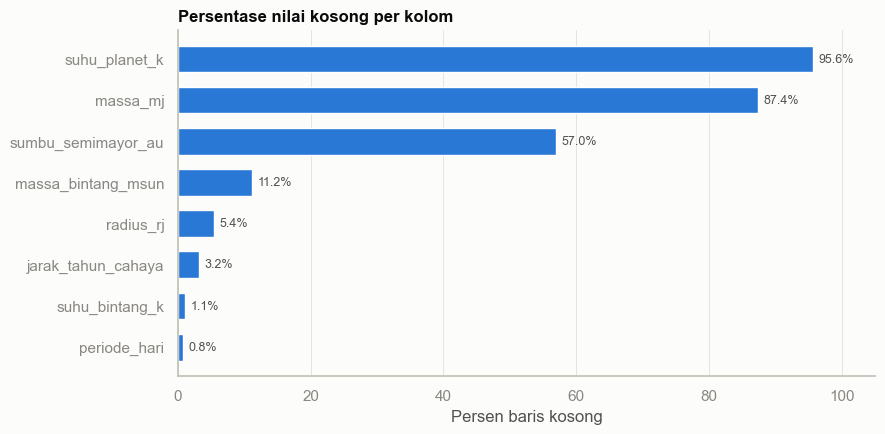

In [12]:
persen_kosong = missing.loc[missing["jumlah_kosong"] > 0, "persen_kosong"].sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(persen_kosong.index, persen_kosong, color=BIRU, height=0.65)
ax.bar_label(ax.containers[0], labels=[f"{v:.1f}%" for v in persen_kosong], padding=4, color=INK2, fontsize=9)
ax.set_xlim(0, 105)
ax.set_xlabel("Persen baris kosong")
ax.set_title("Persentase nilai kosong per kolom", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

### Insight

1. **Sangat parah**: `suhu_planet_k` (95,6%), `massa_mj` (87,4%).
2. **Parah**: `sumbu_semimayor_au` (57,0%).
3. **Sedang**: `massa_bintang_msun` (11,2%).
4. **Ringan**: `radius_rj` (5,4%), `jarak_tahun_cahaya` (3,2%), `suhu_bintang_k` (1,1%), `periode_hari` (0,8%).

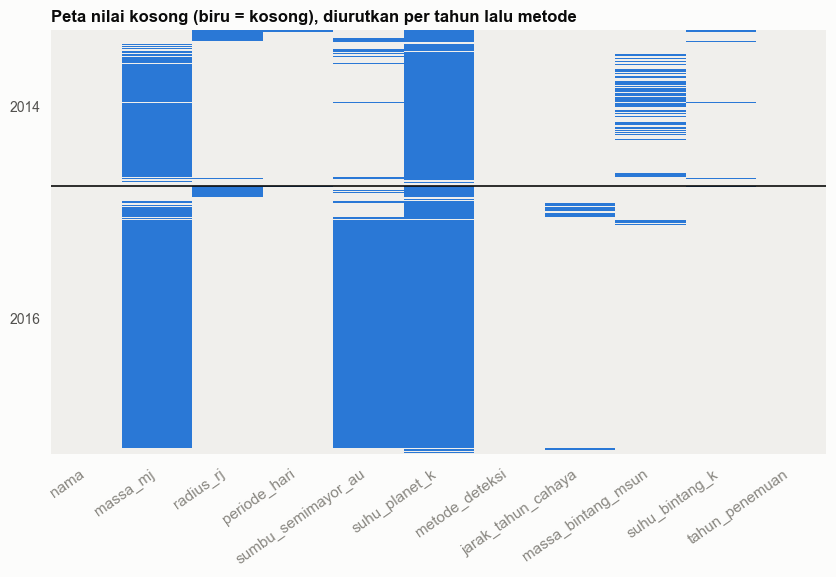

In [13]:
urutan = df.sort_values(["tahun_penemuan", "metode_deteksi"]).index
batas_tahun = (df["tahun_penemuan"] == 2014).sum()

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(df.loc[urutan].isnull(), cmap=ListedColormap([ABU, BIRU]), cbar=False, yticklabels=False, ax=ax)
ax.grid(False)
ax.axhline(batas_tahun, color=INK, linewidth=1.2)
ax.text(-0.15, batas_tahun / 2, "2014", ha="right", va="center", color=INK2, fontsize=10)
ax.text(-0.15, batas_tahun + (len(df) - batas_tahun) / 2, "2016", ha="right", va="center", color=INK2, fontsize=10)
ax.set_title("Peta nilai kosong (biru = kosong), diurutkan per tahun lalu metode", loc="left")
plt.xticks(rotation=35, ha="right")
plt.show()

### Insight

- Nilai kosong **tidak acak**, tetapi membentuk blok.
- `sumbu_semimayor_au` hampir penuh di 2014 tetapi hampir kosong di 2016.
- `massa_bintang_msun` justru banyak kosong di 2014 dan hampir penuh di 2016.
- Baris teratas setiap tahun (metode non-transit) punya pola berbeda: `radius_rj` kosong, `massa_mj` terisi.

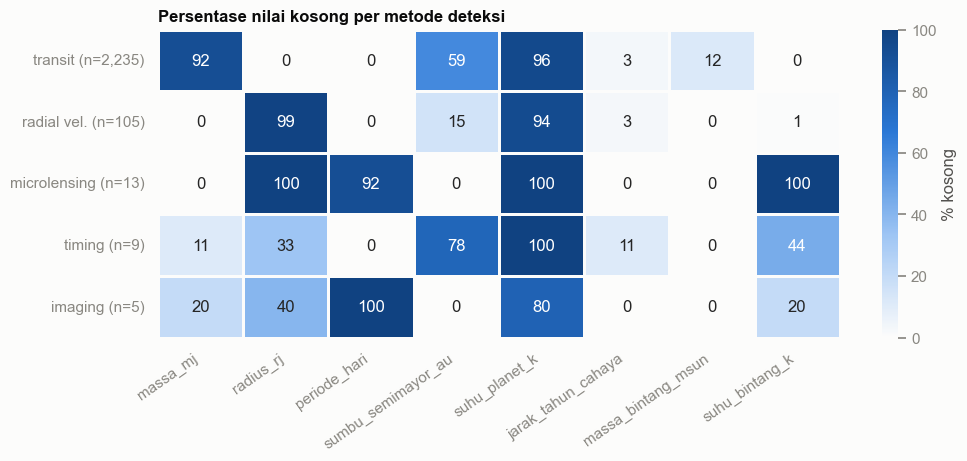

In [14]:
kosong_per_metode = (
    df.drop(columns=["nama", "metode_deteksi", "tahun_penemuan"])
      .isnull()
      .groupby(df["metode_deteksi"])
      .mean()
      .mul(100)
)
jumlah_per_metode = df["metode_deteksi"].value_counts()
kosong_per_metode = kosong_per_metode.loc[jumlah_per_metode.index]
kosong_per_metode.index = [f"{m} (n={n:,})" for m, n in jumlah_per_metode.items()]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(kosong_per_metode, annot=True, fmt=".0f", cmap=CMAP_SEKUENSIAL, vmin=0, vmax=100,
            linewidths=2, linecolor=SURFACE, cbar_kws={"label": "% kosong"}, ax=ax)
ax.grid(False)
ax.set_title("Persentase nilai kosong per metode deteksi", loc="left")
ax.set_ylabel("")
plt.xticks(rotation=35, ha="right")
plt.show()

### Insight

Nilai kosong mengikuti **apa yang bisa diukur oleh setiap metode** (kosong secara struktural):

1. **Transit** mengukur radius, bukan massa: `massa_mj` kosong 92%.
2. **Radial velocity** mengukur massa, bukan radius: `radius_rj` kosong 99%.
3. **Microlensing** tidak menghasilkan periode, radius, maupun suhu bintang (kosong 92-100%).
4. **Imaging** tidak punya `periode_hari` sama sekali (100% kosong).
5. `suhu_planet_k` kosong di semua metode (80-100%).

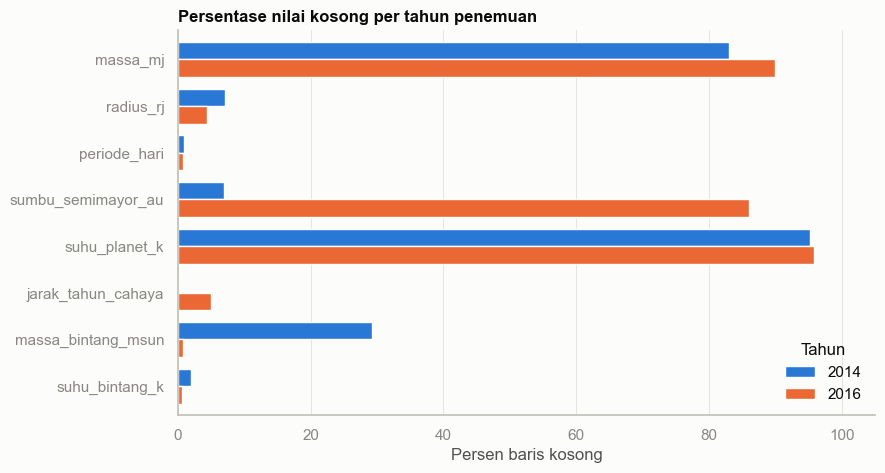

tahun_penemuan,2014,2016
massa_mj,83.0,89.9
radius_rj,7.1,4.3
periode_hari,0.9,0.7
sumbu_semimayor_au,7.0,86.0
suhu_planet_k,95.2,95.9
jarak_tahun_cahaya,0.0,5.1
massa_bintang_msun,29.2,0.8
suhu_bintang_k,2.1,0.6


In [15]:
kosong_per_tahun = (
    df.drop(columns=["nama", "metode_deteksi", "tahun_penemuan"])
      .isnull()
      .groupby(df["tahun_penemuan"])
      .mean()
      .mul(100)
      .T
)

ax = kosong_per_tahun.plot(kind="barh", color=[BIRU, ORANYE], figsize=(9, 5), width=0.75)
ax.set_xlim(0, 105)
ax.set_xlabel("Persen baris kosong")
ax.set_title("Persentase nilai kosong per tahun penemuan", loc="left")
ax.legend(title="Tahun", loc="lower right")
ax.grid(axis="y", visible=False)
ax.invert_yaxis()
plt.show()

kosong_per_tahun.round(1)

### Insight

- `sumbu_semimayor_au`: kosong **7%** di 2014 vs **86%** di 2016.
- `massa_bintang_msun`: kosong **29%** di 2014 vs **1%** di 2016.
- `jarak_tahun_cahaya`: kosong hanya di 2016 (5%).
- Perbedaan sebesar ini berasal dari **kelengkapan tabel sumber** tiap halaman Wikipedia, bukan dari sifat planetnya.

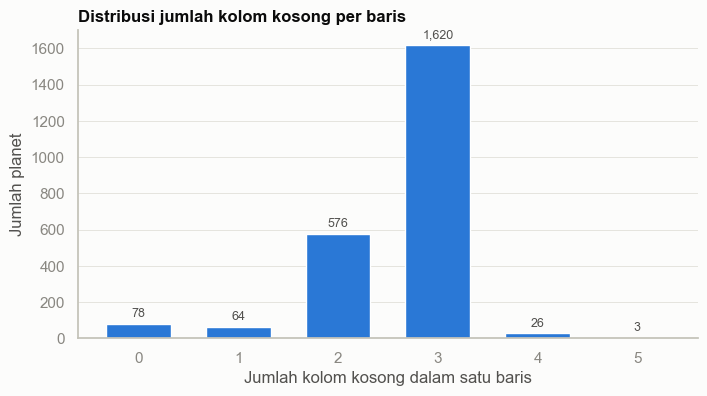

Baris lengkap (tanpa kosong): 78 (3.3%)


In [16]:
kosong_per_baris = df.isnull().sum(axis=1).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(kosong_per_baris.index.astype(str), kosong_per_baris, color=BIRU, width=0.65)
ax.bar_label(ax.containers[0], labels=[f"{v:,}" for v in kosong_per_baris], padding=3, color=INK2, fontsize=9)
ax.set_xlabel("Jumlah kolom kosong dalam satu baris")
ax.set_ylabel("Jumlah planet")
ax.set_title("Distribusi jumlah kolom kosong per baris", loc="left")
ax.grid(axis="x", visible=False)
plt.show()

print("Baris lengkap (tanpa kosong):", df.dropna().shape[0], f"({df.dropna().shape[0] / len(df):.1%})")

### Insight

- Hanya **78 baris (3,3%)** yang lengkap di semua kolom.
- Mayoritas planet (1.620 baris) kosong di **3 kolom** sekaligus.
- Masalah: menghapus baris yang punya nilai kosong akan membuang hampir seluruh data.

## 8. Mendeteksi outlier

Outlier dideteksi dengan boxplot dan IQR score. Tidak ada data yang dihapus di tahap ini.

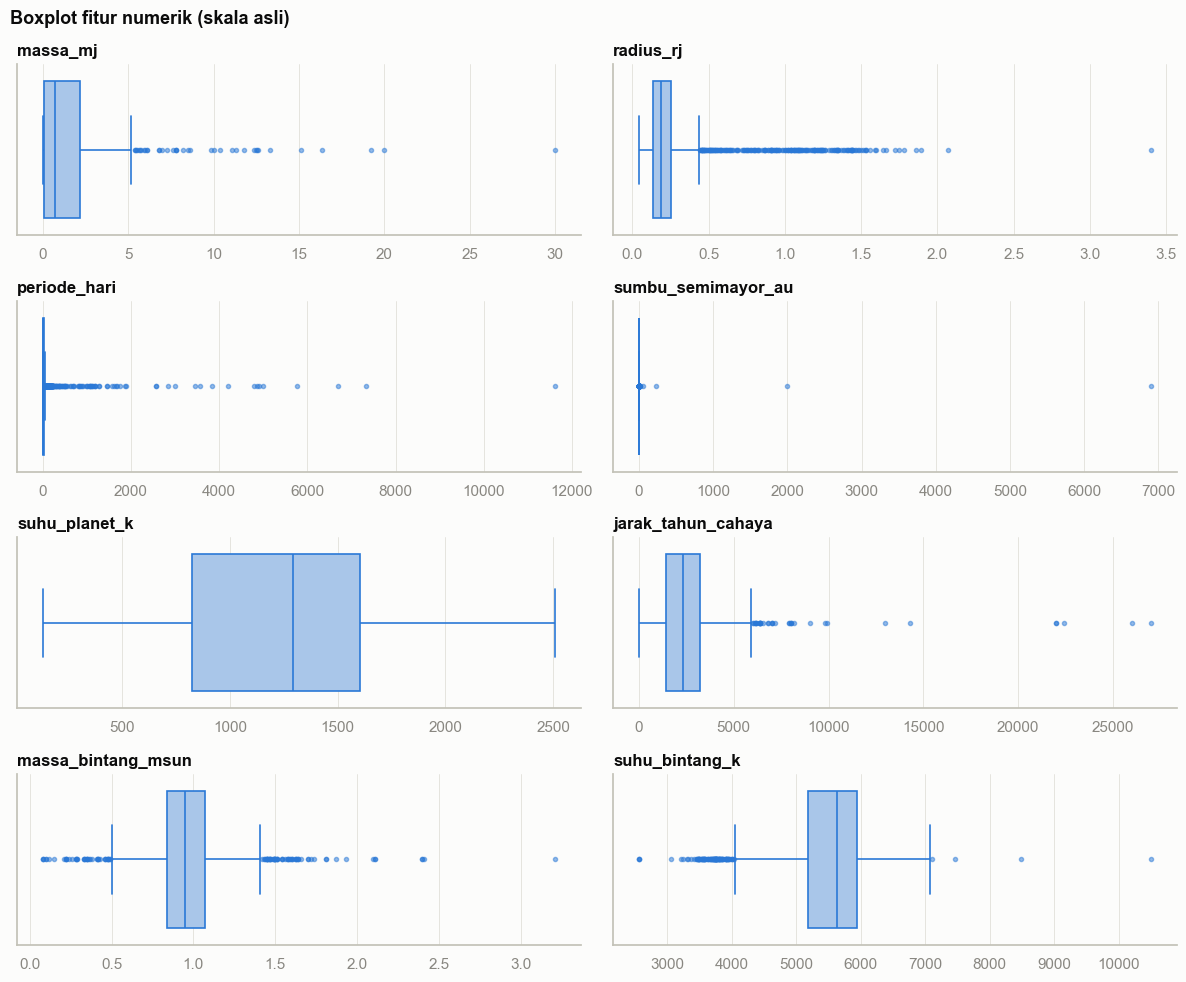

In [17]:
kolom_numerik = df.select_dtypes("number").columns.drop("tahun_penemuan")

fig, axes = plt.subplots(4, 2, figsize=(12, 10))
for ax, kolom in zip(axes.flat, kolom_numerik):
    sns.boxplot(x=df[kolom], ax=ax, color="#9ec5f4", linecolor=BIRU, linewidth=1.2,
                flierprops={"marker": "o", "markersize": 3, "markerfacecolor": BIRU, "markeredgecolor": BIRU, "alpha": 0.5})
    ax.set_title(kolom, loc="left")
    ax.set_xlabel("")
fig.suptitle("Boxplot fitur numerik (skala asli)", x=0.01, ha="left", fontweight="semibold", fontsize=13)
plt.tight_layout()
plt.show()

### Insight

- Pada skala asli, box `periode_hari` dan `sumbu_semimayor_au` tertekan menjadi garis karena beberapa nilai sangat besar (11.613 hari, 6.900 AU).
- `radius_rj` punya deretan panjang outlier atas (0,44-3,4 RJ), yaitu planet raksasa gas.
- Hanya `suhu_planet_k` yang terlihat tanpa outlier.
- `suhu_bintang_k` punya outlier di dua sisi (bintang dingin dan bintang panas).

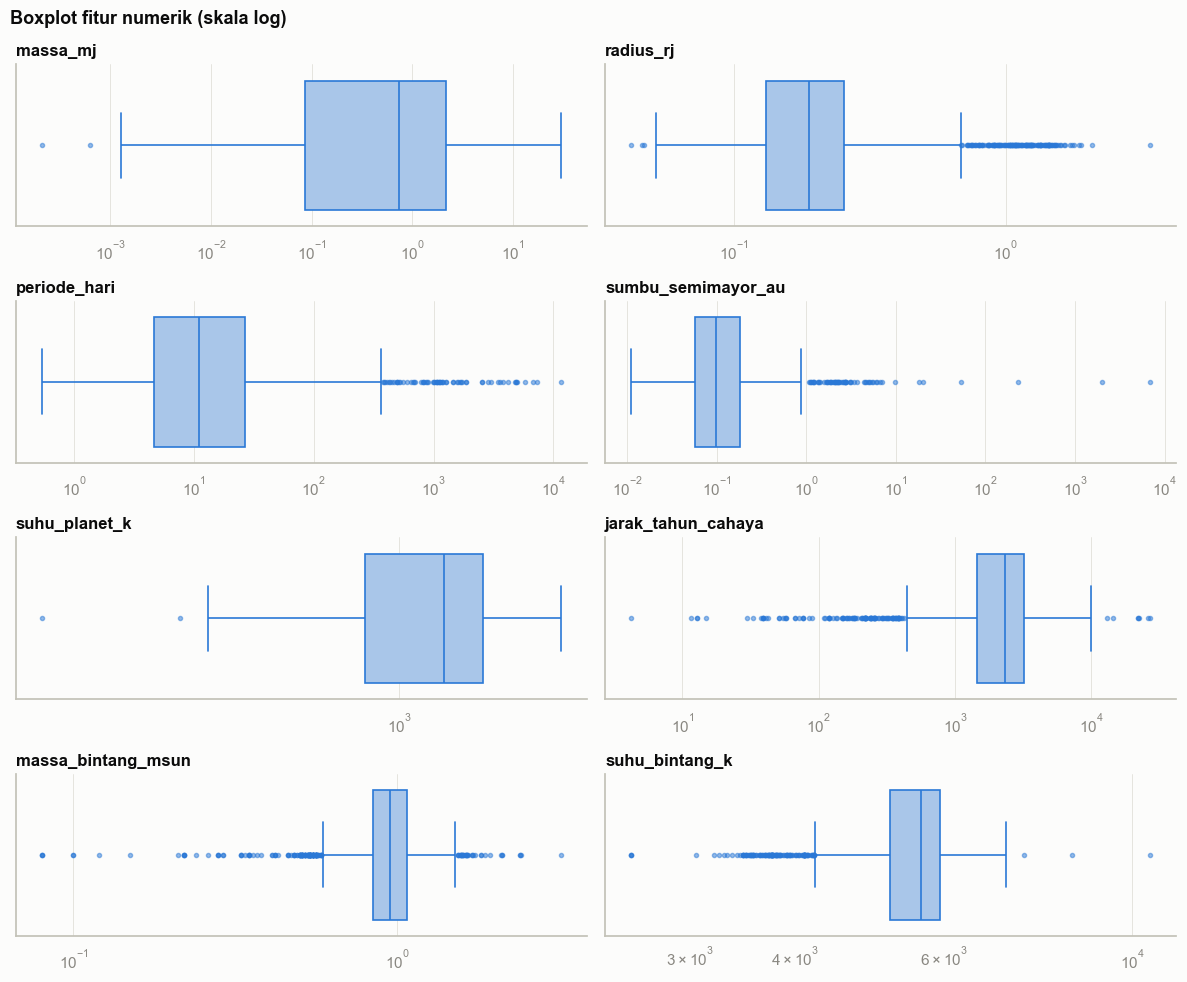

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
for ax, kolom in zip(axes.flat, kolom_numerik):
    sns.boxplot(x=df[kolom], ax=ax, log_scale=True, color="#9ec5f4", linecolor=BIRU, linewidth=1.2,
                flierprops={"marker": "o", "markersize": 3, "markerfacecolor": BIRU, "markeredgecolor": BIRU, "alpha": 0.5})
    ax.set_title(kolom, loc="left")
    ax.set_xlabel("")
fig.suptitle("Boxplot fitur numerik (skala log)", x=0.01, ha="left", fontweight="semibold", fontsize=13)
plt.tight_layout()
plt.show()

### Insight

- Pada skala log, sebaran `periode_hari`, `sumbu_semimayor_au`, dan `massa_mj` jauh lebih mudah dibaca: data menyebar di **beberapa orde besaran**.
- `massa_bintang_msun` dan `suhu_bintang_k` justru terlihat sempit (terkonsentrasi di sekitar nilai bintang mirip Matahari) dengan outlier di kedua sisi.
- `jarak_tahun_cahaya` punya ekor ke kiri (bintang dekat) dan ke kanan (microlensing, puluhan ribu tahun cahaya).

In [19]:
numerik = df[kolom_numerik]
Q1 = numerik.quantile(0.25)
Q3 = numerik.quantile(0.75)
IQR = Q3 - Q1
outlier_iqr = (numerik < (Q1 - 1.5 * IQR)) | (numerik > (Q3 + 1.5 * IQR))

log_numerik = np.log10(numerik)
Q1_log, Q3_log = log_numerik.quantile(0.25), log_numerik.quantile(0.75)
IQR_log = Q3_log - Q1_log
outlier_iqr_log = (log_numerik < (Q1_log - 1.5 * IQR_log)) | (log_numerik > (Q3_log + 1.5 * IQR_log))

ringkasan_outlier = pd.DataFrame({
    "Q1": Q1, "Q3": Q3, "IQR": IQR,
    "batas_bawah": Q1 - 1.5 * IQR, "batas_atas": Q3 + 1.5 * IQR,
    "outlier": outlier_iqr.sum(),
    "outlier_%": (outlier_iqr.sum() / numerik.notna().sum() * 100).round(1),
    "outlier_skala_log": outlier_iqr_log.sum(),
})
print("Baris dengan minimal satu outlier (skala asli):", outlier_iqr.any(axis=1).sum())
ringkasan_outlier.round(3)

Baris dengan minimal satu outlier (skala asli): 626


,Q1,Q3,IQR,batas_bawah,batas_atas,outlier,outlier_%,outlier_skala_log
massa_mj,0.085,2.151,2.066,-3.014,5.250,38,12.7,2
radius_rj,0.132,0.255,0.123,-0.052,0.440,213,9.5,158
periode_hari,4.634,26.681,22.047,-28.437,59.751,289,12.3,67
sumbu_semimayor_au,0.057,0.182,0.125,-0.130,0.369,121,11.9,66
suhu_planet_k,822.750,1604.250,781.500,-349.500,2776.500,0,0.0,2
jarak_tahun_cahaya,1437.000,3230.000,1793.000,-1252.500,5919.500,37,1.6,133
massa_bintang_msun,0.840,1.070,0.230,0.495,1.415,111,5.3,175
suhu_bintang_k,5178.000,5935.000,757.000,4042.500,7070.500,111,4.7,142


### Insight

1. **626 baris** punya minimal satu outlier menurut IQR.
2. Persentase outlier tertinggi: `massa_mj` (12,7%), `periode_hari` (12,3%), `sumbu_semimayor_au` (11,9%), `radius_rj` (9,5%).
3. `batas_bawah` negatif pada kolom yang pasti positif (massa, radius, periode, jarak), jadi di sana hanya **outlier atas** yang mungkin.
4. Dengan IQR skala log, outlier `periode_hari` turun dari 289 ke 67 dan `massa_mj` dari 38 ke 2: sebagian besar "outlier" adalah efek **distribusi yang miring**.

In [20]:
kolom_ekstrem = ["sumbu_semimayor_au", "jarak_tahun_cahaya", "massa_mj", "radius_rj", "periode_hari", "massa_bintang_msun"]
nilai_ekstrem = pd.concat([df.nlargest(2, kolom) for kolom in kolom_ekstrem]).drop_duplicates("nama")
nilai_ekstrem

,nama,massa_mj,radius_rj,periode_hari,sumbu_semimayor_au,suhu_planet_k,metode_deteksi,jarak_tahun_cahaya,massa_bintang_msun,suhu_bintang_k,tahun_penemuan
869,2MASS J2126-8140,13.30,NaN,NaN,6900.0000,1800.0,imaging,111.40,0.53,3490.0,2016
16,GU Piscium b,11.30,1.265,NaN,2000.0000,NaN,imaging,160.00,0.33,3250.0,2014
2326,OGLE-2015-BLG-0051Lb,0.72,NaN,NaN,0.7300,NaN,microlensing,27000.00,0.10,NaN,2016
838,OGLE-2008-BLG-92Lb,0.18,NaN,NaN,18.0000,NaN,microlensing,26000.00,0.71,NaN,2014
947,HR 2562 b,30.00,1.110,NaN,20.3000,NaN,imaging,109.70,1.30,NaN,2016
41,HIP 97233 b,20.00,NaN,1058.800000,2.5500,NaN,radial vel.,347.00,1.93,5020.0,2014
30,HD 100546 b,NaN,3.400,NaN,53.0000,NaN,imaging,320.00,2.40,10500.0,2014
2365,XO-6b,4.40,2.070,3.765001,0.0815,1577.0,transit,759.00,1.47,6720.0,2016
905,HD 30177 c,7.60,NaN,11613.000000,9.8900,NaN,radial vel.,178.40,0.99,5580.0,2016
875,Gliese 676 Ac,6.80,NaN,7337.000000,6.6000,NaN,radial vel.,55.00,0.71,NaN,2016


### Insight

Nilai paling ekstrem **masuk akal secara fisik**, tetapi berasal dari metode minoritas:

1. `2MASS J2126-8140` (imaging): orbit **6.900 AU**, planet yang sangat jauh dari bintangnya.
2. `OGLE-...` (microlensing): jarak **22.000-27.000 tahun cahaya**, ke arah pusat galaksi.
3. `HR 2562 b` (30 MJ) dan planet lain di atas **13 MJ**: melewati batas umum planet, kemungkinan katai coklat.
4. `HD 100546 b` (imaging): radius **3,4 RJ** dengan bintang 10.500 K.
5. `HD 30177 c` (radial velocity): periode **11.613 hari** (~32 tahun).

Masalah: outlier ini bukan salah input, melainkan **populasi berbeda** (metode deteksi berbeda).

## 9. Plot fitur terhadap frekuensi (histogram) dan terhadap fitur lain (heatmap, scatter)

### Histogram / distribusi tiap fitur

#### Fitur kategorik

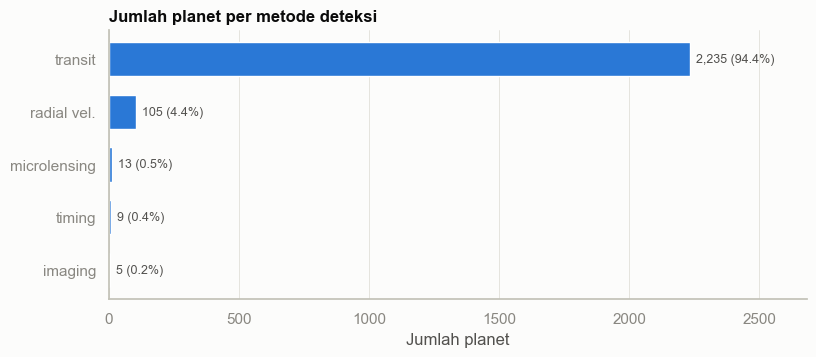

In [21]:
jumlah_metode = df["metode_deteksi"].value_counts()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(jumlah_metode.index, jumlah_metode, color=BIRU, height=0.65)
ax.bar_label(ax.containers[0], labels=[f"{v:,} ({v / len(df):.1%})" for v in jumlah_metode], padding=4, color=INK2, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, jumlah_metode.max() * 1.2)
ax.set_xlabel("Jumlah planet")
ax.set_title("Jumlah planet per metode deteksi", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

### Insight

- **Transit mendominasi: 2.235 planet (94,4%)**.
- Radial velocity 105 (4,4%); microlensing, timing, dan imaging masing-masing di bawah 1%.
- Masalah: **kelas sangat tidak seimbang**; kategori kecil (5-13 planet) terlalu sedikit untuk dianalisis sendiri.

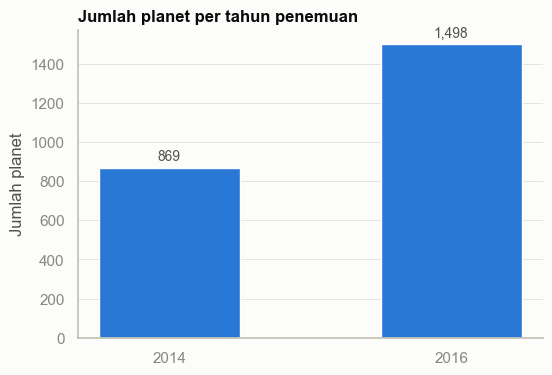

tahun_penemuan,2014,2016,total
metode_deteksi,,,
imaging,2,3,5
microlensing,6,7,13
radial vel.,52,53,105
timing,8,1,9
transit,801,1434,2235
total,869,1498,2367


In [22]:
jumlah_tahun = df["tahun_penemuan"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(jumlah_tahun.index.astype(str), jumlah_tahun, color=BIRU, width=0.5)
ax.bar_label(ax.containers[0], labels=[f"{v:,}" for v in jumlah_tahun], padding=3, color=INK2, fontsize=10)
ax.set_ylabel("Jumlah planet")
ax.set_title("Jumlah planet per tahun penemuan", loc="left")
ax.grid(axis="x", visible=False)
plt.show()

pd.crosstab(df["metode_deteksi"], df["tahun_penemuan"], margins=True, margins_name="total")

### Insight

- 2016 menyumbang **1.498 planet (63%)**, hampir dua kali lipat 2014 (869).
- Kenaikan hampir seluruhnya dari **transit** (801 menjadi 1.434); metode lain relatif sama.
- Metode timing turun dari 8 menjadi 1 planet.

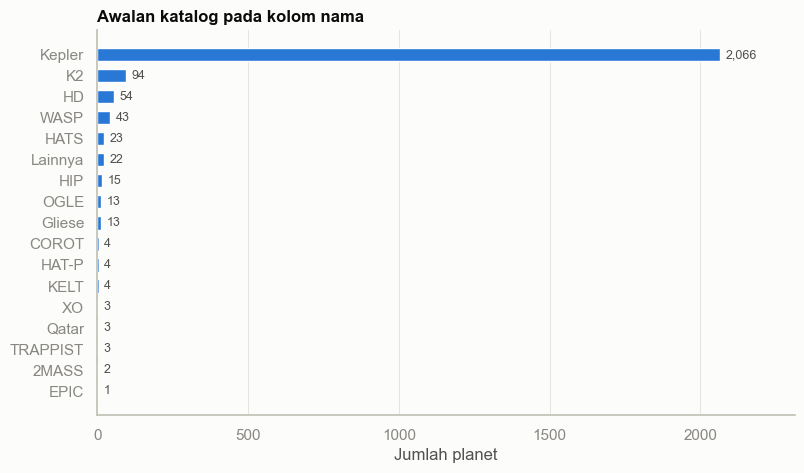

In [23]:
awalan_katalog = (
    df["nama"]
      .str.extract(r"^(Kepler|K2|WASP|HAT-P|HATS|KELT|OGLE|HD|HIP|Gliese|2MASS|COROT|Qatar|XO|EPIC|TRAPPIST|KOI)")[0]
      .fillna("Lainnya")
)
jumlah_katalog = awalan_katalog.value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(jumlah_katalog.index, jumlah_katalog, color=BIRU, height=0.65)
ax.bar_label(ax.containers[0], labels=[f"{v:,}" for v in jumlah_katalog], padding=4, color=INK2, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, jumlah_katalog.max() * 1.12)
ax.set_xlabel("Jumlah planet")
ax.set_title("Awalan katalog pada kolom nama", loc="left")
ax.grid(axis="y", visible=False)
plt.show()

### Insight

- `nama` tidak berguna langsung, tetapi awalannya menunjukkan **survei asal** planet.
- **Kepler: 2.066 planet (87%)**, disusul K2 (94) dan HD (54).
- Masalah: data sangat bergantung pada satu misi, sehingga karakteristik planet (radius kecil, jarak jauh) mencerminkan **bias survei Kepler**.

#### Fitur numerik

In [24]:
def plot_distribusi(kolom, skala_log=False, bins=40):
    data = df[kolom].dropna()
    median = data.median()

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(data, bins=bins, log_scale=skala_log, color=BIRU, edgecolor=SURFACE, linewidth=1, alpha=1, ax=ax)
    ax.axvline(median, color=INK, linewidth=1.5)
    ax.text(median, ax.get_ylim()[1] * 0.97, f"  median = {median:,.4g}", color=INK, fontsize=9, va="top")
    skala = " (sumbu x skala log)" if skala_log else ""
    ax.set_title(f"Distribusi {kolom}{skala}  |  n = {len(data):,}, kosong = {df[kolom].isnull().sum():,}", loc="left")
    ax.set_ylabel("Jumlah planet")
    ax.grid(axis="x", visible=False)
    plt.show()

    return data.describe().to_frame().T.assign(skewness=data.skew()).round(3)

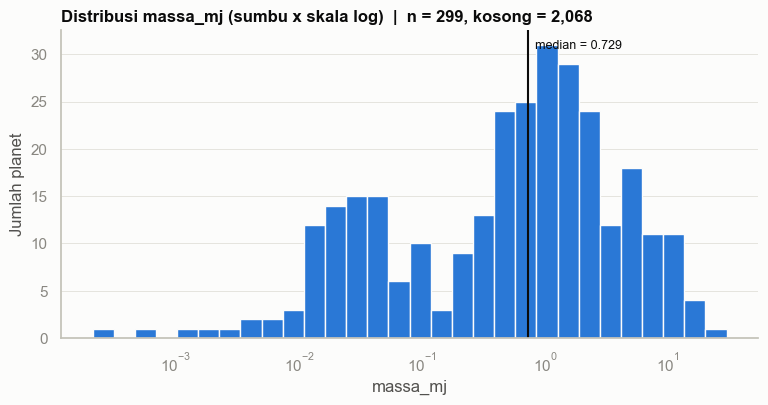

,count,mean,std,min,25%,50%,75%,max,skewness
massa_mj,299.0,2.073,3.632,0.0,0.085,0.729,2.151,30.0,3.472


In [25]:
plot_distribusi("massa_mj", skala_log=True, bins=30)

### Insight

- Hanya **299 planet** yang punya massa.
- Rentang sangat lebar: 0,0002 hingga 30 MJ (median 0,73 MJ), skewness 3,47 pada skala asli.
- Pada skala log, sebaran cenderung **dua kelompok**: planet kecil (< 0,1 MJ, 79 planet) dan planet raksasa (sekitar 1 MJ).
- 6 planet di atas 13 MJ, kemungkinan bukan planet.

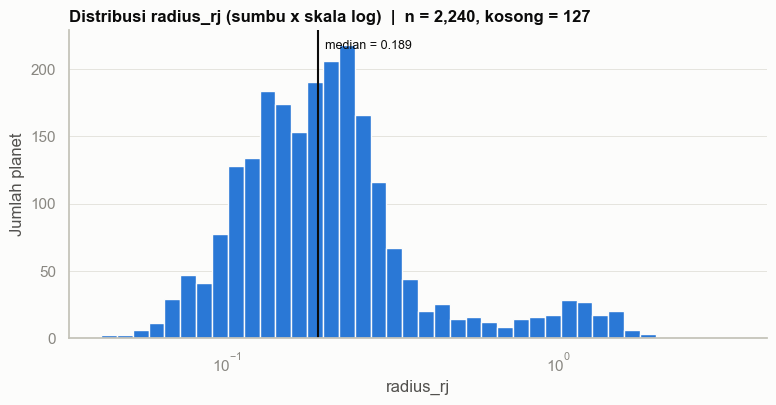

,count,mean,std,min,25%,50%,75%,max,skewness
radius_rj,2240.0,0.263,0.276,0.042,0.132,0.189,0.255,3.4,3.612


In [26]:
plot_distribusi("radius_rj", skala_log=True)

### Insight

- Median **0,189 RJ** (sekitar 2 kali radius Bumi).
- **1.843 planet (82%)** berukuran 0,09-0,36 RJ (1-4 radius Bumi), kelompok super-Bumi dan sub-Neptunus.
- Ada **puncak kedua kecil di sekitar 1 RJ**: 138 planet > 0,8 RJ (raksasa gas), maksimum 3,4 RJ.
- Skewness 3,61 pada skala asli.

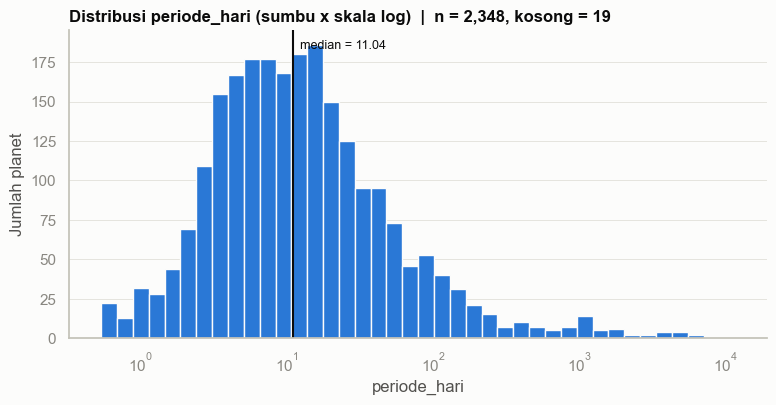

,count,mean,std,min,25%,50%,75%,max,skewness
periode_hari,2348.0,77.301,459.522,0.538,4.634,11.039,26.681,11613.0,13.96


In [27]:
plot_distribusi("periode_hari", skala_log=True)

### Insight

- Median **11 hari**; 1.102 planet (47%) mengorbit dalam < 10 hari.
- Rentang 0,54 hingga 11.613 hari, **skewness 13,96** pada skala asli.
- Hanya 67 planet dengan periode > 1 tahun.
- Periode pendek mendominasi karena transit lebih mudah mendeteksi planet yang sering melintas.

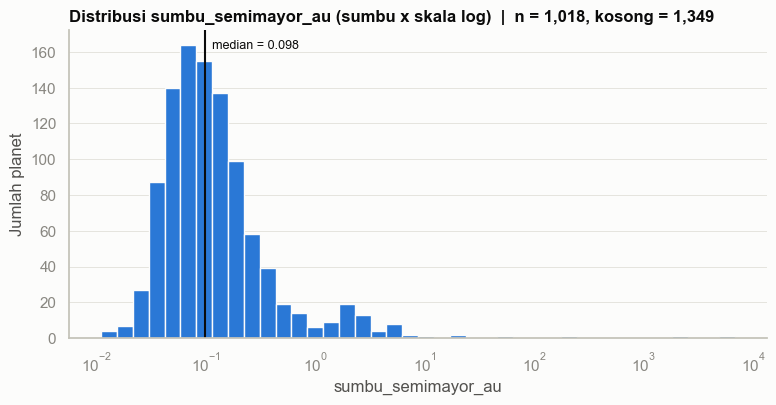

,count,mean,std,min,25%,50%,75%,max,skewness
sumbu_semimayor_au,1018.0,9.352,225.202,0.011,0.057,0.098,0.182,6900.0,28.904


In [28]:
plot_distribusi("sumbu_semimayor_au", skala_log=True)

### Insight

- Hanya 1.018 planet terisi; median **0,098 AU** (lebih dekat dari Merkurius ke Matahari).
- **Skewness 28,9** pada skala asli, tertinggi dari semua kolom, karena satu nilai 6.900 AU.
- 515 planet (51% dari yang terisi) berada < 0,1 AU dari bintangnya.

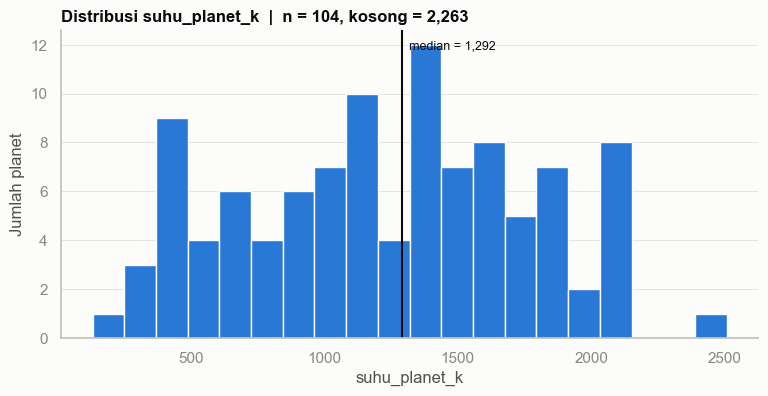

,count,mean,std,min,25%,50%,75%,max,skewness
suhu_planet_k,104.0,1232.308,534.783,131.0,822.75,1292.0,1604.25,2508.0,-0.037


In [29]:
plot_distribusi("suhu_planet_k", bins=20)

### Insight

- Hanya **104 planet** terisi.
- Tersebar lebar dan cukup merata (skewness -0,04), median **1.292 K**, rentang 131-2.508 K.
- Masalah: sampel kecil dan didominasi planet panas yang dekat bintang, sehingga **tidak mewakili** seluruh data.

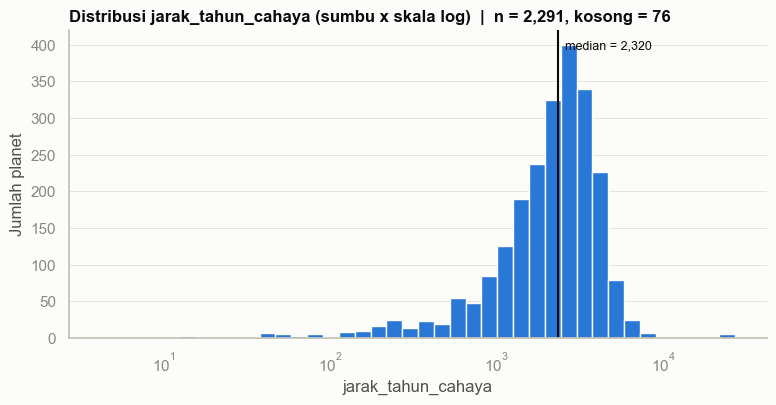

,count,mean,std,min,25%,50%,75%,max,skewness
jarak_tahun_cahaya,2291.0,2470.103,1707.256,4.2,1437.0,2320.0,3230.0,27000.0,4.987


In [30]:
plot_distribusi("jarak_tahun_cahaya", skala_log=True)

### Insight

- Median **2.320 tahun cahaya**, kebanyakan planet jauh (khas target Kepler).
- Ekor kiri: 28 planet < 100 tahun cahaya (umumnya radial velocity).
- Ekor kanan: 74 planet > 5.000 tahun cahaya, maksimum 27.000 (microlensing).
- Skewness 4,99 pada skala asli.

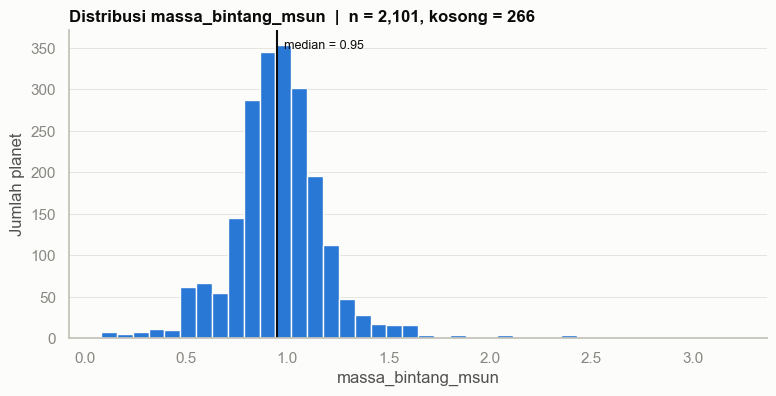

,count,mean,std,min,25%,50%,75%,max,skewness
massa_bintang_msun,2101.0,0.955,0.239,0.08,0.84,0.95,1.07,3.21,0.789


In [31]:
plot_distribusi("massa_bintang_msun")

### Insight

- Median **0,95 massa Matahari**; **1.504 bintang (72%)** bermassa 0,8-1,2 Msun (mirip Matahari).
- Ekor kanan hingga 3,21 Msun, ekor kiri hingga 0,08 Msun (katai merah).
- Skewness 0,79, cukup mendekati normal dibanding fitur planet.

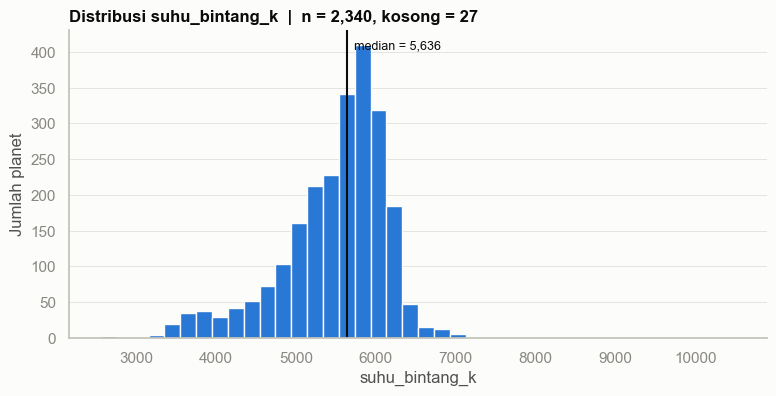

,count,mean,std,min,25%,50%,75%,max,skewness
suhu_bintang_k,2340.0,5488.815,669.083,2559.0,5178.0,5636.5,5935.0,10500.0,-0.819


In [32]:
plot_distribusi("suhu_bintang_k")

### Insight

- Median **5.636 K**; **1.407 bintang (60%)** bersuhu 5.000-6.000 K (tipe G, seperti Matahari).
- Miring ke kiri (skewness -0,82): 103 bintang dingin < 4.000 K (katai M).
- Hanya 9 bintang > 7.000 K, maksimum 10.500 K.

### Heat Maps

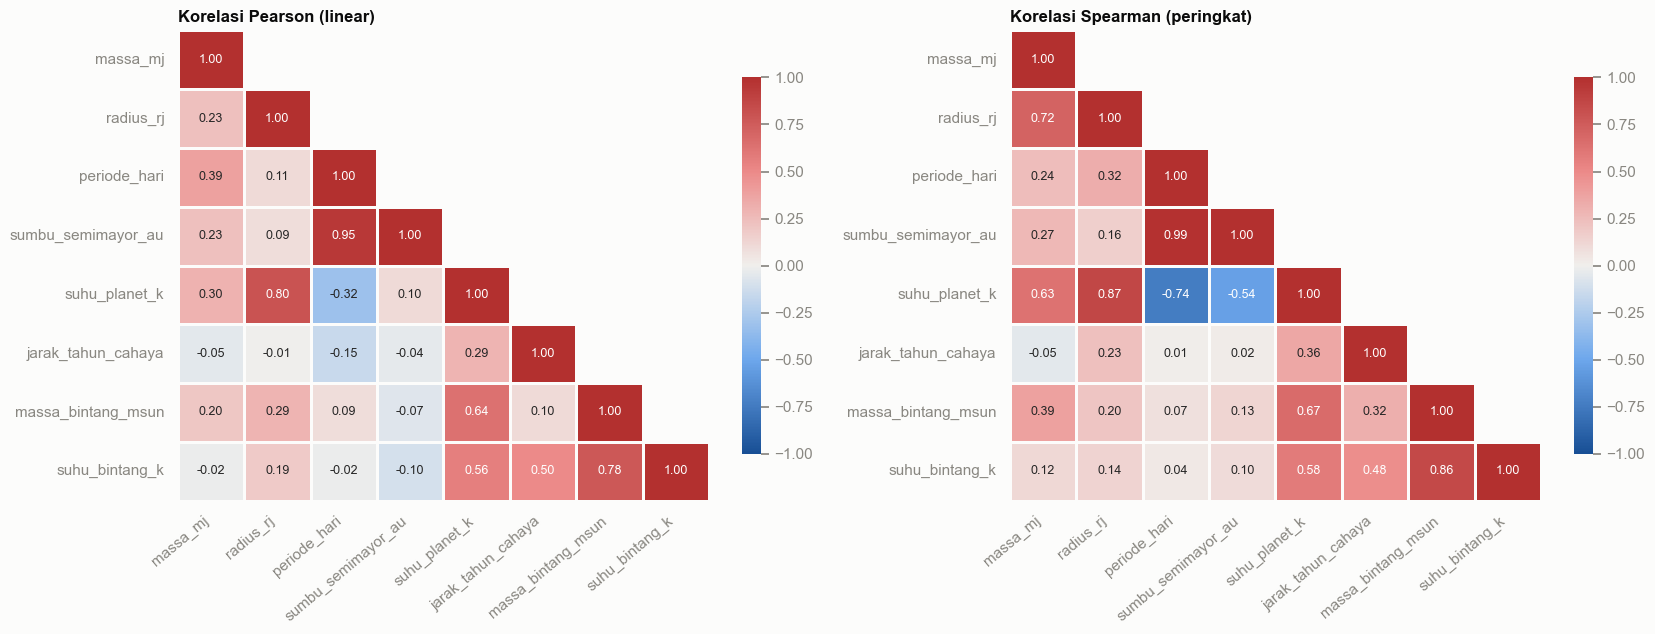

,massa_mj,radius_rj,periode_hari,sumbu_semimayor_au,suhu_planet_k,jarak_tahun_cahaya,massa_bintang_msun,suhu_bintang_k
massa_mj,1.00,0.23,0.39,0.23,0.30,-0.05,0.20,-0.02
radius_rj,0.23,1.00,0.11,0.09,0.80,-0.01,0.29,0.19
periode_hari,0.39,0.11,1.00,0.95,-0.32,-0.15,0.09,-0.02
sumbu_semimayor_au,0.23,0.09,0.95,1.00,0.10,-0.04,-0.07,-0.10
suhu_planet_k,0.30,0.80,-0.32,0.10,1.00,0.29,0.64,0.56
jarak_tahun_cahaya,-0.05,-0.01,-0.15,-0.04,0.29,1.00,0.10,0.50
massa_bintang_msun,0.20,0.29,0.09,-0.07,0.64,0.10,1.00,0.78
suhu_bintang_k,-0.02,0.19,-0.02,-0.10,0.56,0.50,0.78,1.00


In [33]:
mask = np.triu(np.ones((len(kolom_numerik), len(kolom_numerik)), dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, metode, judul in zip(axes, ["pearson", "spearman"], ["Korelasi Pearson (linear)", "Korelasi Spearman (peringkat)"]):
    c = numerik.corr(method=metode)
    sns.heatmap(c, mask=mask, cmap=CMAP_DIVERGING, vmin=-1, vmax=1, annot=True, fmt=".2f",
                linewidths=2, linecolor=SURFACE, annot_kws={"fontsize": 9}, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.grid(False)
    ax.set_title(judul, loc="left")
    ax.tick_params(axis="x", rotation=40)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.tight_layout()
plt.show()

numerik.corr(method="pearson").round(2)

### Insight

1. `periode_hari` - `sumbu_semimayor_au`: **0,95 (Pearson), 0,99 (Spearman)**, hubungan hukum Kepler; kedua kolom **redundan**.
2. `massa_bintang_msun` - `suhu_bintang_k`: **0,78 / 0,86**, bintang lebih masif lebih panas.
3. `radius_rj` - `suhu_planet_k`: **0,80 / 0,87**, tetapi hanya dari ~97 pasangan data.
4. `periode_hari` - `suhu_planet_k`: -0,32 (Pearson) vs **-0,74 (Spearman)**, planet yang dekat bintang lebih panas.
5. `massa_mj` - `radius_rj`: 0,23 (Pearson) vs **0,72 (Spearman)**.

Masalah: selisih besar Pearson vs Spearman menunjukkan hubungan **tidak linear** dan Pearson terdistorsi oleh skew dan outlier.

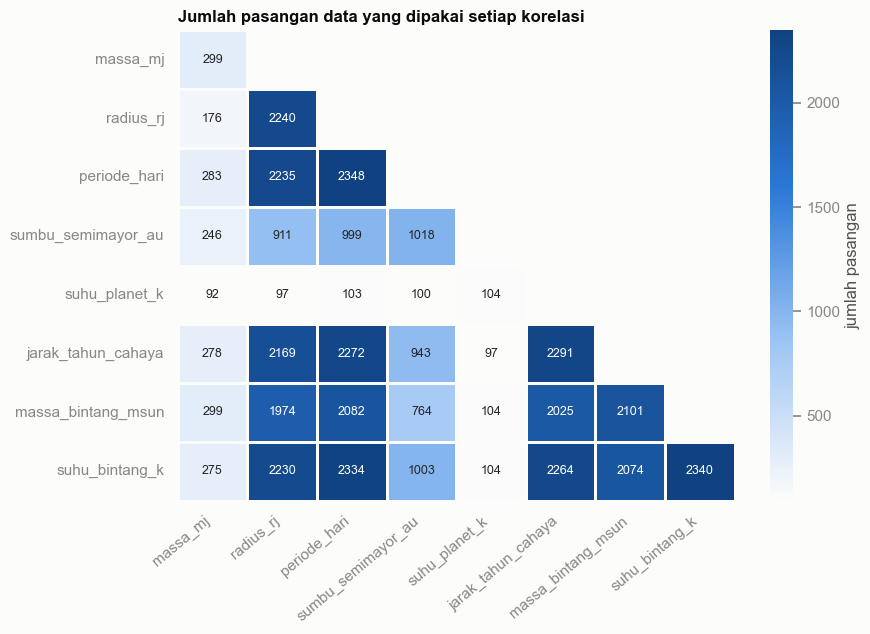

In [34]:
n_pasangan = numerik.notna().astype(int).T @ numerik.notna().astype(int)

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(n_pasangan, mask=mask, cmap=CMAP_SEKUENSIAL, annot=True, fmt="d",
            linewidths=2, linecolor=SURFACE, annot_kws={"fontsize": 9}, cbar_kws={"label": "jumlah pasangan"}, ax=ax)
ax.grid(False)
ax.set_title("Jumlah pasangan data yang dipakai setiap korelasi", loc="left")
ax.tick_params(axis="x", rotation=40)
for label in ax.get_xticklabels():
    label.set_ha("right")
plt.tight_layout()
plt.show()

### Insight

- Korelasi yang melibatkan `suhu_planet_k` hanya dihitung dari **92-104 pasangan**, dan `massa_mj` dari 176-299 pasangan.
- Korelasi antar kolom yang terisi baik (radius, periode, jarak, bintang) memakai **>1.900 pasangan**, jauh lebih dapat dipercaya.
- Masalah: setiap nilai korelasi dihitung dari subset baris yang berbeda, sehingga tidak bisa dibandingkan langsung.

### Scatterplot

Warna menunjukkan metode deteksi. Microlensing, timing, dan imaging digabung menjadi **lainnya** karena jumlahnya kecil.

In [35]:
kelompok_metode = df["metode_deteksi"].where(df["metode_deteksi"].isin(["transit", "radial vel."]), "lainnya")


def plot_sebar(x, y, log_x=True, log_y=True):
    data = df[[x, y]].assign(metode=kelompok_metode).dropna()

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.scatterplot(data=data, x=x, y=y, hue="metode", hue_order=list(WARNA_METODE), palette=WARNA_METODE,
                    s=36, alpha=0.75, edgecolor=SURFACE, linewidth=0.8, ax=ax)
    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")
    ax.set_title(f"{y} vs {x}  |  n = {len(data):,} pasangan lengkap", loc="left")
    ax.legend(title="Metode deteksi", loc="best")
    plt.show()

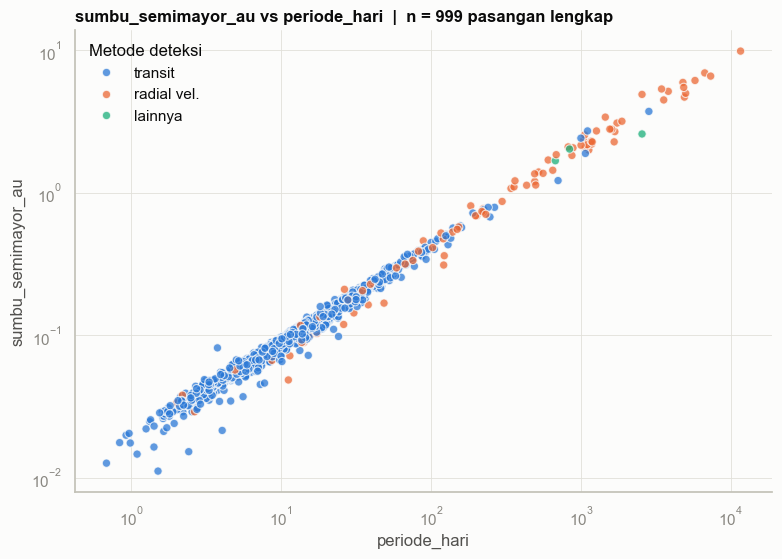

In [36]:
plot_sebar("periode_hari", "sumbu_semimayor_au")

### Insight

- Titik membentuk **garis lurus** pada skala log-log, sesuai hukum Kepler III (a³ ∝ P²).
- Transit berkumpul di periode pendek, radial velocity di periode panjang.
- Beberapa titik sedikit keluar dari garis, dicek di bawah.

In [37]:
cek_kepler = df.dropna(subset=["periode_hari", "sumbu_semimayor_au", "massa_bintang_msun"]).copy()
# Hukum Kepler III (AU, tahun, massa Matahari): a^3 / (P^2 * M) ~ 1
cek_kepler["rasio_kepler"] = cek_kepler["sumbu_semimayor_au"] ** 3 / ((cek_kepler["periode_hari"] / 365.25) ** 2 * cek_kepler["massa_bintang_msun"])

print(cek_kepler["rasio_kepler"].describe().round(3))
cek_kepler.loc[~cek_kepler["rasio_kepler"].between(0.5, 2),
               ["nama", "periode_hari", "sumbu_semimayor_au", "massa_bintang_msun", "metode_deteksi", "rasio_kepler"]]

count    745.000
mean       1.034
std        0.145
min        0.429
25%        0.996
50%        1.006
75%        1.074
max        3.466
Name: rasio_kepler, dtype: float64


,nama,periode_hari,sumbu_semimayor_au,massa_bintang_msun,metode_deteksi,rasio_kepler
285,Kepler-186c,7.267302,0.0451,0.54,transit,0.429111
2365,XO-6b,3.765001,0.0815,1.47,transit,3.465819


### Insight

- Dari 745 planet yang punya periode, sumbu semimayor, dan massa bintang, **median rasio = 1,006**: nilai ketiga kolom konsisten.
- Hanya **2 planet** yang tidak konsisten (rasio di luar 0,5-2): `Kepler-186c` (0,43) dan `XO-6b` (3,47).
- Masalah: kedua baris ini kemungkinan **salah nilai** pada salah satu kolom.

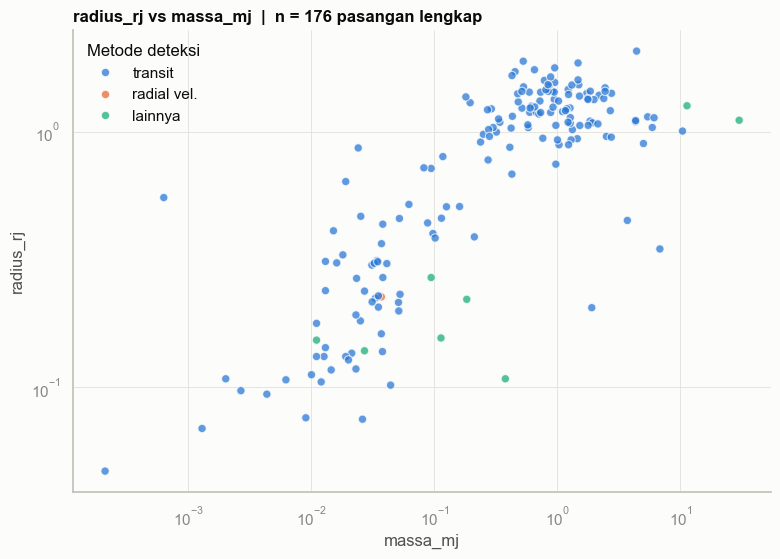

In [38]:
plot_sebar("massa_mj", "radius_rj")

### Insight

- Hanya **176 planet** yang punya massa dan radius sekaligus.
- Planet < ~0,3 MJ: radius naik seiring massa.
- Planet > ~0,3 MJ: radius **mendatar di sekitar 1 RJ** meski massa naik puluhan kali lipat.
- Hubungan ini tidak linear, sesuai selisih Pearson (0,23) dan Spearman (0,72).
- Beberapa titik menyimpang dari pola, misalnya massa < 0,001 MJ dengan radius ~0,5 RJ.

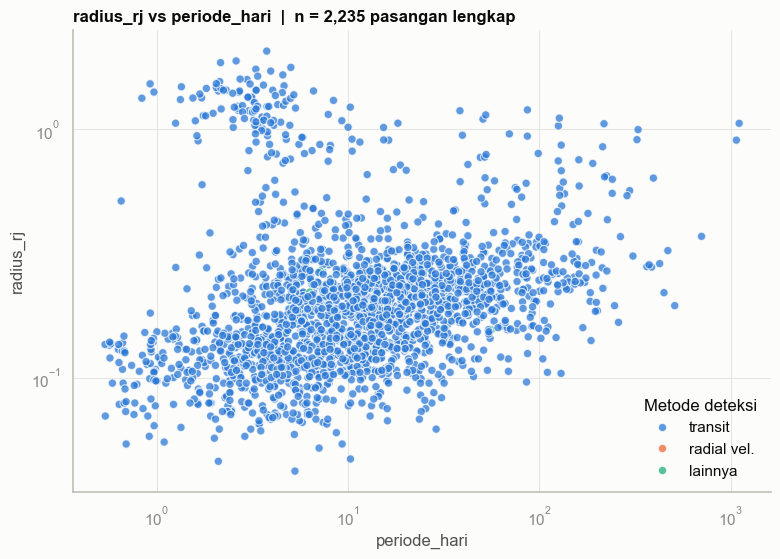

In [39]:
plot_sebar("periode_hari", "radius_rj")

### Insight

- Hampir semua titik adalah **transit**, karena planet radial velocity tidak punya radius.
- Mayoritas planet berada di **radius 0,1-0,4 RJ dan periode 1-100 hari**.
- Terlihat kelompok **hot Jupiter**: radius ~1 RJ dengan periode < 10 hari.
- Hampir tidak ada planet kecil dengan periode panjang: batas kemampuan deteksi, bukan berarti planet tersebut tidak ada.

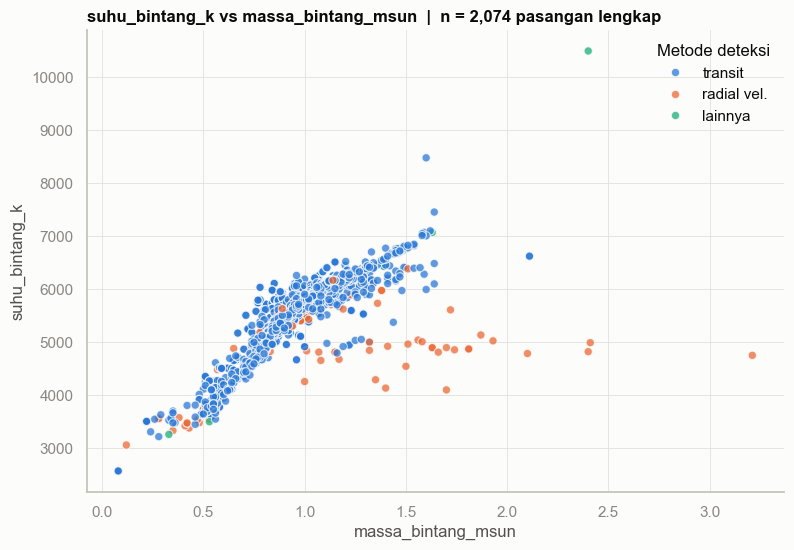

In [40]:
plot_sebar("massa_bintang_msun", "suhu_bintang_k", log_x=False, log_y=False)

### Insight

- Bintang induk planet **transit** mengikuti tren naik yang rapat: lebih masif, **lebih panas**.
- Bintang **radial velocity** bermassa > 1,3 Msun justru mendatar di **4.000-5.600 K**, keluar dari tren (kemungkinan bintang raksasa yang sudah berevolusi).
- Titik ekstrem: bintang 10.500 K (imaging, `HD 100546 b`) dan satu bintang transit ~8.500 K.

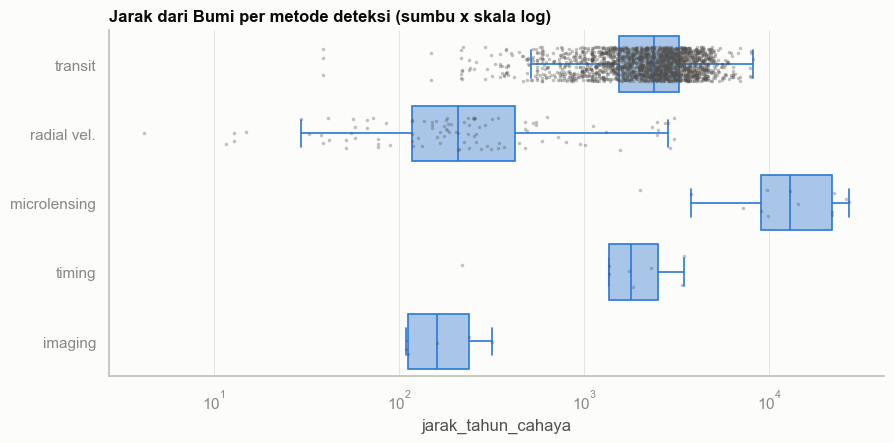

,count,mean,std,min,25%,50%,75%,max
metode_deteksi,,,,,,,,
imaging,5.0,188.2,90.7,109.7,111.4,160.0,240.0,320.0
microlensing,13.0,14491.5,8482.5,2000.0,9000.0,13000.0,22000.0,27000.0
radial vel.,102.0,482.8,750.6,4.2,118.0,208.3,424.8,3060.0
timing,8.0,1957.2,1080.5,220.0,1364.0,1790.0,2565.0,3450.0
transit,2163.0,2498.7,1260.4,39.0,1550.0,2390.0,3265.0,8190.0


In [41]:
urutan_metode = df["metode_deteksi"].value_counts().index

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=df, x="jarak_tahun_cahaya", y="metode_deteksi", order=urutan_metode, log_scale=True,
            color="#9ec5f4", linecolor=BIRU, linewidth=1.2, showfliers=False, ax=ax)
sns.stripplot(data=df, x="jarak_tahun_cahaya", y="metode_deteksi", order=urutan_metode,
              color=INK2, size=2.5, alpha=0.35, jitter=0.25, ax=ax)
ax.set_title("Jarak dari Bumi per metode deteksi (sumbu x skala log)", loc="left")
ax.set_ylabel("")
plt.show()

df.groupby("metode_deteksi")["jarak_tahun_cahaya"].describe().round(1)

### Insight

- Jarak sangat bergantung pada metode:
    1. **Imaging** median 160 dan **radial velocity** median 208 tahun cahaya (bintang dekat);
    2. **Transit** median 2.390 tahun cahaya;
    3. **Microlensing** median 13.000 tahun cahaya.
- Masalah: `metode_deteksi` memengaruhi distribusi hampir semua fitur, sehingga data berisi **beberapa populasi** yang berbeda.

## Ringkasan masalah untuk tahap preprocessing

1. **Missing values berat dan struktural**: `suhu_planet_k` 95,6%, `massa_mj` 87,4%, `sumbu_semimayor_au` 57%; hanya 78 baris lengkap. Pola kosong bergantung pada metode deteksi dan tahun (tabel sumber).
2. **Distribusi sangat miring**: periode, sumbu semimayor, massa, radius, dan jarak menyebar di beberapa orde besaran.
3. **Outlier valid secara fisik**: 626 baris ditandai IQR; nilai paling ekstrem berasal dari metode minoritas, 6 objek > 13 MJ kemungkinan bukan planet, dan bintang radial velocity keluar dari tren massa-suhu.
4. **Kelas tidak seimbang**: transit 94,4%, dan 87% planet dari misi Kepler.
5. **Fitur redundan**: `periode_hari` dan `sumbu_semimayor_au` berkorelasi 0,99 (Spearman).
6. **Inkonsistensi nilai**: 2 planet (`Kepler-186c`, `XO-6b`) melanggar hukum Kepler III.
7. **Kolom identitas**: `nama` unik di setiap baris; `tahun_penemuan` hanya 2 nilai.